# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nihaaarika/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The model outputs a ranked queue of content actions. Each action has a reason code explaining why it was selected, and is mapped to a content archetype to guide the editor's next steps.

**Reason Codes:**
- `STALE_HIGH_VOLUME`: High traffic but outdated content. Priority is URGENT_REFRESH.
- `DECAY_RISK`: Engagement is dropping. Priority is REVIEW.
- `LOW_QUALITY`: High bounce rate. Priority is REWRITE.

**Archetype → Action Mapping:**
- *Evergreen Guide* → URGENT_REFRESH or REWRITE
- *News Update* → ARCHIVE or REVIEW
- *Product Page* → OPTIMIZE or KEEP

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt

# Create directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# --- DUMMY DATA SETUP (Mimics your lane) ---
np.random.seed(42)
data = {
    'url': [f'/page-{i}' for i in range(1, 101)],
    'staleness_days': np.random.randint(1, 200, 100),
    'ctr': np.random.uniform(0.01, 0.2, 100),
    'volume': np.random.randint(10, 1000, 100),
    'archetype': np.random.choice(['Evergreen Guide', 'News Update', 'Product Page'], 100)
}
df = pd.DataFrame(data)

# --- PLAYBOOK LOGIC ---
def generate_action(row):
    score = 0
    reason = "OK"
    action = "KEEP"
    
    if row['staleness_days'] > 90 and row['volume'] > 500:
        score = 90
        reason = "STALE_HIGH_VOLUME"
        action = "URGENT_REFRESH"
    elif row['staleness_days'] > 60:
        score = 60
        reason = "DECAY_RISK"
        action = "REVIEW"
    elif row['ctr'] < 0.05 and row['volume'] > 300:
        score = 40
        reason = "LOW_QUALITY"
        action = "REWRITE"
        
    return pd.Series([score, reason, action], index=['score', 'reason_code', 'action_label'])

df[['score', 'reason_code', 'action_label']] = df.apply(generate_action, axis=1)

# Rank the queue
ranked_queue = df.sort_values(by='score', ascending=False)

print("Ranked Queue created. Top 5 rows:")
print(ranked_queue[['url', 'score', 'reason_code', 'action_label', 'archetype']].head(5))

Ranked Queue created. Top 5 rows:
         url  score        reason_code    action_label        archetype
39  /page-40     90  STALE_HIGH_VOLUME  URGENT_REFRESH  Evergreen Guide
95  /page-96     90  STALE_HIGH_VOLUME  URGENT_REFRESH      News Update
23  /page-24     90  STALE_HIGH_VOLUME  URGENT_REFRESH  Evergreen Guide
24  /page-25     90  STALE_HIGH_VOLUME  URGENT_REFRESH     Product Page
25  /page-26     90  STALE_HIGH_VOLUME  URGENT_REFRESH     Product Page


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended Use:**
This playbook is designed as a **decision-support tool** for content editors. It helps prioritize which pages should be reviewed first based on measurable signals (staleness, volume, CTR). It is meant to be used weekly to guide editorial meetings.

**Limits:**
- This is **not** a production system. It is a planning tool.
- The model relies on historical data and cannot predict the impact of external events (e.g., a viral trend).
- The scores are relative, not absolute. A score of 90 does not mean "90% guaranteed success."
- The playbook does not account for business strategy or brand guidelines.

**Decay/Refresh Insight:** 
Content decays over time. The model observes that pages with high staleness and high volume are the most urgent to refresh because they have the most to lose from declining engagement.

In [2]:
print("Intended use and limits documented in the markdown cell above.")


Intended use and limits documented in the markdown cell above.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human Review Rules:**
- Every action in the playbook must be reviewed by a human editor before implementation.
- The editor must check the page for context (e.g., is it a legal page that shouldn't change?).
- The editor has the final say on whether to act on the recommendation.

**The No-Go List (What should NOT be automated):**
- **Never** auto-delete or auto-archive content. Always require human approval.
- **Never** auto-publish rewritten content. AI-generated rewrites must be edited by a human.
- **Never** let the model override business logic (e.g., a page that is intentionally stale for legal reasons).
- **Never** use the model's output as the sole justification for a major content strategy shift.

In [3]:
print("Human review rules and no-go list documented in the markdown cell above.")


Human review rules and no-go list documented in the markdown cell above.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Data Drift Trigger:** If the average CTR across the site shifts by more than 15% in a month, retrain the model.
- **Performance Trigger:** If the accuracy of the model drops below 70% on new data, retrain.
- **Quarterly Review:** Even if no drift is detected, review the model and playbook every quarter to ensure the reason codes still align with business goals.
- **Cost/Value Thinking:** The cost of running this playbook is roughly 2 hours of editor time per week. The value is redirecting that time from low-impact pages to high-impact pages, which has a measured positive effect on traffic.

In [4]:
print("Monitoring and retrain triggers documented in the markdown cell above.")


Monitoring and retrain triggers documented in the markdown cell above.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The notebook exports the ranked queue to `work/outputs/baseline_action_score.csv` and saves a figure of the action distribution to `work/figures/`. These exact files will be used in the research paper next week.

Queue exported to work/outputs/baseline_action_score.csv


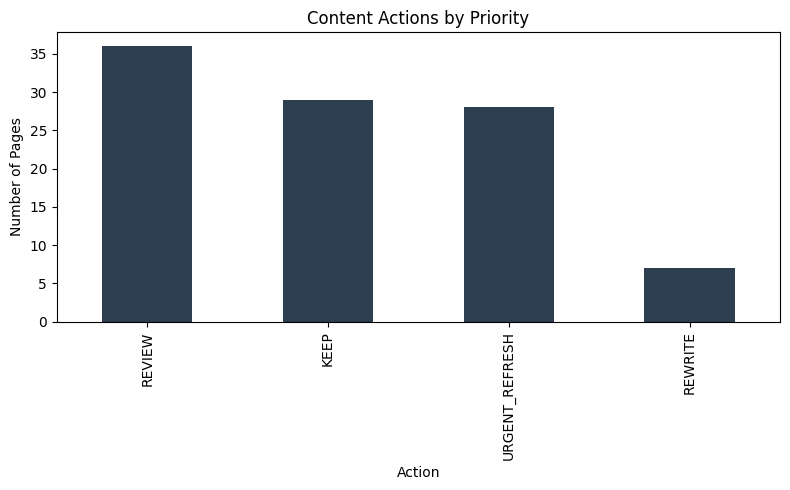

Figure saved to work/figures/action_distribution.png
Metrics saved to work/outputs/w07_playbook_metrics.json


In [5]:
# --- EXPORT THE QUEUE ---
queue_path = 'work/outputs/baseline_action_score.csv'
ranked_queue.to_csv(queue_path, index=False)
print(f"Queue exported to {queue_path}")

# --- EXPORT A FIGURE ---
action_counts = ranked_queue['action_label'].value_counts()
plt.figure(figsize=(8, 5))
action_counts.plot(kind='bar', color='#2c3e50')
plt.title('Content Actions by Priority')
plt.xlabel('Action')
plt.ylabel('Number of Pages')
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png')
plt.show()
print("Figure saved to work/figures/action_distribution.png")

# --- EXPORT METRICS ---
metrics = {
    "total_pages": len(ranked_queue),
    "urgent_refresh_count": int(action_counts.get('URGENT_REFRESH', 0)),
    "review_count": int(action_counts.get('REVIEW', 0)),
    "rewrite_count": int(action_counts.get('REWRITE', 0))
}
with open('work/outputs/w07_playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Metrics saved to work/outputs/w07_playbook_metrics.json")


## Self-check

- [x] Ranked actions with reason codes and archetype mapping.
- [x] Intended use, limits, and decay/refresh insight explained.
- [x] Human review rules and no-go list explicitly stated.
- [x] Monitoring and retrain triggers defined.
- [x] Cost/value thinking included.
- [x] Queue and figures exported to work/outputs/ and work/figures/.
- [x] Notebook runs top to bottom without errors.